In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [26]:
df = pd.read_csv('/workspaces/SML/SML /Exp 7/diabetes2.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [27]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [28]:
df.corr

<bound method DataFrame.corr of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   5

In [29]:
print(df.columns.tolist())

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [30]:
df.shape

(768, 9)

In [31]:
X = df.iloc[:, 0:8]  # Features: Columns 0, 1, 2, 3, 4, 5, 6, 7
y = df.iloc[:, 8]    # Target: Column 8 (Outcome)

In [32]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')
sc = StandardScaler()
X_train_scaled=sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

classifier = LogisticRegression()
parameter = [{'l1_ratio':[1.0],'solver':['liblinear','saga'],
     'C':[1,2,3,4,5],'max_iter':[1000]},
    {'l1_ratio':[0.0],'solver':['lbfgs','liblinear','saga'],
     'C':[1,2,3,4,5],'max_iter':[1000]},
    {
        # ElasticNet (Combination of L1 and L2)
        'penalty': ['elasticnet'],
        'solver': ['saga'],
        'l1_ratio': [0.5], # Must be a float
        'C': [1, 2, 3, 4, 5]
    }
]


In [34]:
grid = GridSearchCV(classifier,param_grid=parameter,cv=5,scoring='accuracy')
grid.fit(X_train_scaled,y_train)
print("Best Parametrs:",grid.best_params_)
print("Best Score",grid.best_score_)

Best Parametrs: {'C': 2, 'l1_ratio': 1.0, 'max_iter': 1000, 'solver': 'liblinear'}
Best Score 0.7777211394302849


In [35]:
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)
import matplotlib.pyplot as plt
#use the model
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_scaled)
y_prob =grid.best_estimator_.predict_proba(X_test_scaled)
accuracy = accuracy_score(y_test,y_pred)
# Use 'macro' or 'weighted' if you have more than two categories
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test,y_pred,average='weighted')
f1 = f1_score(y_test,y_pred,average='weighted')
print("Accuracy:",accuracy)
print("precision:",precision)
print("recall:",recall)
print("f1:",f1)

Accuracy: 0.7291666666666666
precision: 0.7329558535743065
recall: 0.7291666666666666
f1: 0.7307429286462578


In [37]:
from sklearn.metrics import classification_report
print("\nClassifcation Report:\n")
print(classification_report(y_test,y_pred))




Classifcation Report:

              precision    recall  f1-score   support

           0       0.80      0.77      0.79       123
           1       0.62      0.65      0.63        69

    accuracy                           0.73       192
   macro avg       0.71      0.71      0.71       192
weighted avg       0.73      0.73      0.73       192



In [38]:
y.shape

(768,)

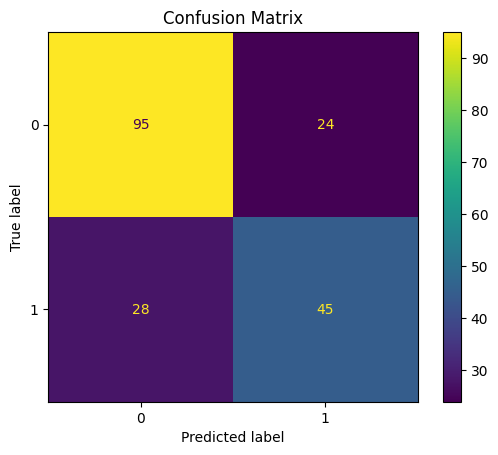

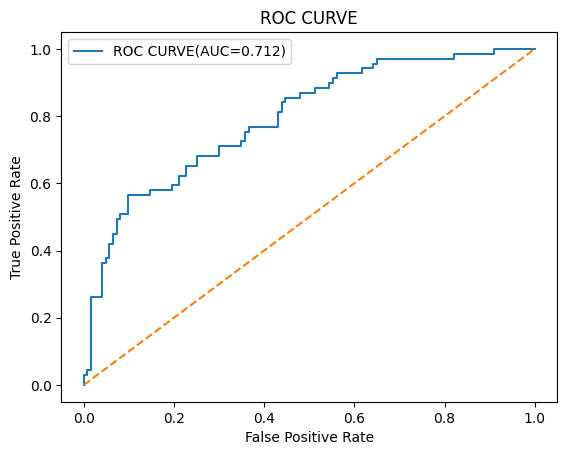

In [39]:
cm = confusion_matrix(y_pred,y_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix')
plt.show()
fpr,tpr,thresholds = roc_curve(y_test,y_prob[:,1])

roc_auc = roc_auc_score(y_test,y_pred)
plt.plot(fpr,tpr,label=f"ROC CURVE(AUC={roc_auc:.3f})")
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC CURVE')
plt.legend()
plt.show()

